In [ ]:
import torch
from rdkit import Chem, RDLogger
from src.mlconfgen import MLConformerGenerator, evaluate_samples
from src.mlconfgen.utils import standardize_mol
from pharmacophore import color_tanimoto

RDLogger.DisableLog('rdApp.*')

if torch.cuda.is_available():
    device = torch.device("cuda:0")
elif torch.backends.mps.is_available():
    device = torch.device("mps:0")
else:
    device = torch.device("cpu")

print(f"Intitialising model on {device}")

generator = MLConformerGenerator(
                                 edm_weights="./edm_moi_chembl_15_39.pt",
                                 adj_mat_seer_weights="./adj_mat_seer_chembl_15_39.pt",
                                 device=device,
                                 diffusion_steps=10,
                                )

ref_mol = Chem.MolFromMolFile('./assets/demo_files/yibfeu.mol')

def score(mols):
    try:
        mols = [standardize_mol(x, optimize_geometry=True, ifm_mode=True) for x in mols]
        ref_mb, scores = evaluate_samples(ref_mol, mols)

        # color_sim = color_tanimoto(aligned_ref, aligned_cand)
        return [x['shape_tanimoto'] for x in scores]
    except:
         return 0
    

generator.fine_tune(
                  scoring_function=score,  # This should output normalised score from (0, 1)
                  reference_conformer=ref_mol,
                  variance= 1,
                  # RL Fine-tune params
                  n_epochs=100,
                  train_batch_size=16,
                  eval_batch_size=16,
                  lambda_edm_adapter=1.5,
                  lambda_edm_reg=0.2,
                  learning_rate= 8e-5,
                  sigma=60.0,
                  temperature=1.5,
                  n_samples_per_mol=8,
                  reward_clip=(-1.0, 1.0),
                  eval_every=2,
                  save_dir="./rl_checkpoints_validity",
    
)



Intitialising model on mps:0


Generation started...
Generation complete in 45.46
AVERAGE SHAPE SIMILARITY - 0.4471428571428572
VALID SAMPLES - 70.0 %


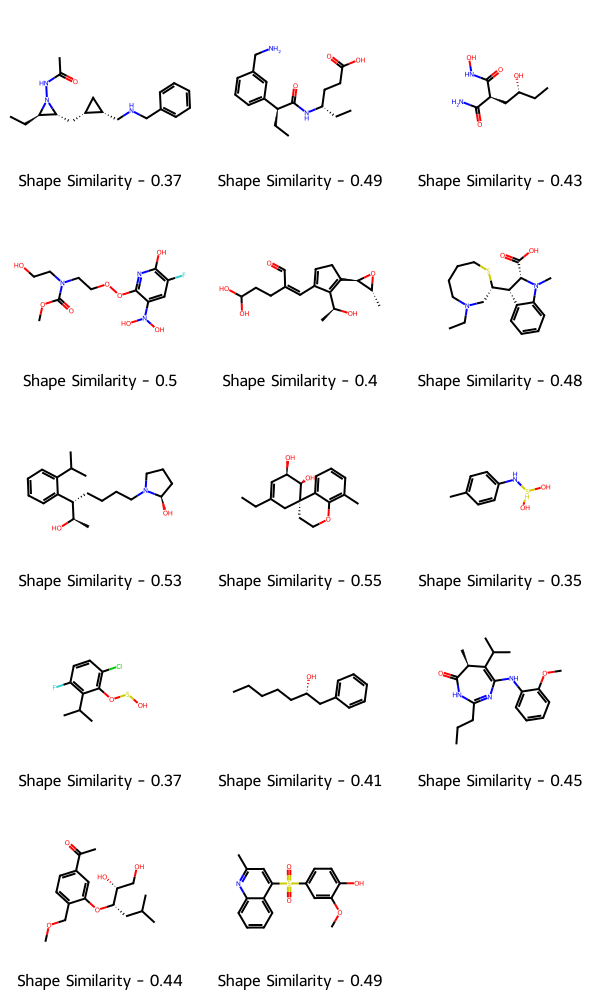

In [17]:
import time
import torch

from rdkit import Chem, RDLogger
from rdkit.Chem import Draw

from src.mlconfgen import MLConformerGenerator, evaluate_samples
RDLogger.DisableLog('rdApp.*')

if torch.cuda.is_available():
    device = torch.device("cuda:0")
elif torch.backends.mps.is_available():
    device = torch.device("mps:0")
else:
    device = torch.device("cpu")


generator = MLConformerGenerator(
                                 edm_weights="./edm_moi_chembl_15_39.pt",
                                 adj_mat_seer_weights="./adj_mat_seer_chembl_15_39.pt",
                                 device=device,
                                 diffusion_steps=20,
                                )

# Load checkpoint
generator.load_finetune_checkpoint("./rl_checkpoints_validity/latest_checkpoint.pt")

# Load a Reference conformer
ref_mol = Chem.MolFromMolFile('./assets/demo_files/yibfeu.mol')


# Generate Samples
print("Generation started...")
start = time.time()

# Resampling significantly increases generation quality, while sacrificing speed
N_SAMPLES = 20
samples = generator.generate_conformers(
                                        reference_conformer=ref_mol,
                                        n_samples=N_SAMPLES,
                                        variance=1,
                                        resample_steps=0,
                                        )

print(f"Generation complete in {round(time.time() - start, 2)}")

# Characterise samples   
_, std_samples = evaluate_samples(ref_mol, samples)

# Display results
mols = []
legends = []
average_shape_similarity = 0
for sample in std_samples:
    mol = Chem.MolFromMolBlock(sample['mol_block'])
    mol = Chem.MolFromSmiles(Chem.MolToSmiles(mol))
    mol.SetProp("Shape_Tanimoto", str(sample['shape_tanimoto']))
    mols.append(mol)
    legends.append(f"Shape Similarity - {round(sample['shape_tanimoto'], 2)}")
    average_shape_similarity += round(sample['shape_tanimoto'], 2)

average_shape_similarity = average_shape_similarity / len(std_samples)
print(f"AVERAGE SHAPE SIMILARITY - {average_shape_similarity}")
print(f"VALID SAMPLES - {round(len(std_samples) / N_SAMPLES, 2) * 100} %")
    
Draw.MolsToGridImage(mols, legends=legends)

In [1]:
from src.mlconfgen import MLConformerGenerator
from onnx_export import export_to_onnx

generator = MLConformerGenerator(
                                 edm_weights="./edm_moi_chembl_15_39.pt",
                                 adj_mat_seer_weights="./adj_mat_seer_chembl_15_39.pt",
                                 diffusion_steps=100,
                                )
# generator.load_fine_tune_checkpoint("./rl_checkpoints_validity/latest_checkpoint.pt")

export_to_onnx(model=generator)

[00:48:40] Initializing Normalizer
[00:48:41] Initializing Normalizer


[torch.onnx] Obtain model graph for `EGNNDynamics([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `EGNNDynamics([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/Users/denissapegin/miniconda3/lib/python3.10/copyreg.py:101: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Check the ONNX model...
[torch.onnx] Check the ONNX model... ✅
[torch.onnx] Execute the model with ONNX Runtime...
[torch.onnx] Execute the model with ONNX Runtime... ✅
[torch.onnx] Verify output accuracy...
[torch.onnx] Verify output accuracy... ✅


/Users/denissapegin/miniconda3/lib/python3.10/site-packages/torch/onnx/_internal/exporter/_onnx_program.py:460: UserWarning: # The axis name: batch_size will not be used, since it shares the same shape constraints with another axis: batch_size.
  rename_mapping = _dynamic_shapes.create_rename_mapping(
/Users/denissapegin/miniconda3/lib/python3.10/site-packages/torch/onnx/_internal/exporter/_onnx_program.py:460: UserWarning: # The axis name: num_nodes will not be used, since it shares the same shape constraints with another axis: num_nodes.
  rename_mapping = _dynamic_shapes.create_rename_mapping(
2026-04-08 00:48:48 | INFO | Removed 28 unused nodes
2026-04-08 00:48:48 | INFO | No unused functions to remove


...

[torch.onnx] Execute the model with ONNX Runtime... ✅
[torch.onnx] Verify output accuracy...
[torch.onnx] Verify output accuracy... ✅
Applied 6 of general pattern rewrite rules.


2026-04-08 00:48:49 | INFO | Skipping constant folding for node 'node_embedding' because it is graph input to preserve graph signature
2026-04-08 00:48:49 | INFO | Skipping constant folding for node 'node_sum_1' because it is graph input to preserve graph signature
2026-04-08 00:48:49 | INFO | Skipping constant folding for node 'node_mul_12' because it is graph input to preserve graph signature
2026-04-08 00:48:49 | INFO | Skipping constant folding for node 'node_embedding_1' because it is graph input to preserve graph signature
2026-04-08 00:48:49 | INFO | Skipping constant folding for node 'node_sum_2' because it is graph input to preserve graph signature
2026-04-08 00:48:49 | INFO | Skipping constant folding for node 'node_mul_61' because it is graph input to preserve graph signature
2026-04-08 00:48:49 | INFO | Removed 6 unused nodes
2026-04-08 00:48:49 | INFO | No unused functions to remove
2026-04-08 00:48:49 | INFO | Replaced initializer 'val_32' with existing initializer 'val_5

[torch.onnx] Obtain model graph for `ExportableAdaptor([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ExportableAdaptor([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/Users/denissapegin/miniconda3/lib/python3.10/copyreg.py:101: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
/Users/denissapegin/miniconda3/lib/python3.10/site-packages/torch/onnx/_internal/exporter/_onnx_program.py:460: UserWarning: # The axis name: batch_size will not be used, since it shares the same shape constraints with another axis: batch_size.
  rename_mapping = _dynamic_shapes.create_rename_mapping(
/Users/denissapegin/miniconda3/lib/python3.10/site-packages/torch/onnx/_internal/exporter/_onnx_program.py:460: UserWarning: # The axis name: num_nodes will not be used, since it shares the same shape constraints with another axis: num_nodes.
  rename_mapping = _dynamic_shapes.create_rename_mapping(
2026-04-08 00:48:52 | INFO | Removed 34 unused nodes
2026-04-08 00:48:52 | INFO | No unused functions to remove


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Check the ONNX model...
[torch.onnx] Check the ONNX model... ✅
[torch.onnx] Execute the model with ONNX Runtime...
[torch.onnx] Execute the model with ONNX Runtime... ✅
[torch.onnx] Verify output accuracy...
[torch.onnx] Verify output accuracy... ✅


In [1]:
from pathlib import Path
from rdkit import Chem
from rdkit.Chem import Draw
from src.mlconfgen import MLConformerGeneratorONNX

artifacts_dir = "./test_rl_fine_tuning"
ceyyag = Chem.MolFromMolFile("./assets/demo_files/ceyyag.mol")

edm, adj, ft =  (
                    Path(f"{artifacts_dir}/egnn_chembl_15_39.onnx"),
                    Path(f"{artifacts_dir}/adj_mat_seer_chembl_15_39.onnx"),
                    Path(f"{artifacts_dir}/finetune_checkpoint.onnx"),
                    )

generator = MLConformerGeneratorONNX(
        egnn_onnx=edm,
        adj_mat_seer_onnx=adj,
        finetune_checkpoint_onnx=ft,
        diffusion_steps=20,
    )

samples = generator.generate_conformers(
        reference_conformer=ceyyag,
        n_samples=20,
        variance=1,
        resample_steps=0,
    )

Draw.MolsToGridImage([Chem.MolFromSmiles(Chem.MolToSmiles(x)) for x in samples])


[16:08:16] Initializing Normalizer


InvalidArgument: [ONNXRuntimeError] : 2 : INVALID_ARGUMENT : Unexpected input data type. Actual: (tensor(double)) , expected: (tensor(float))

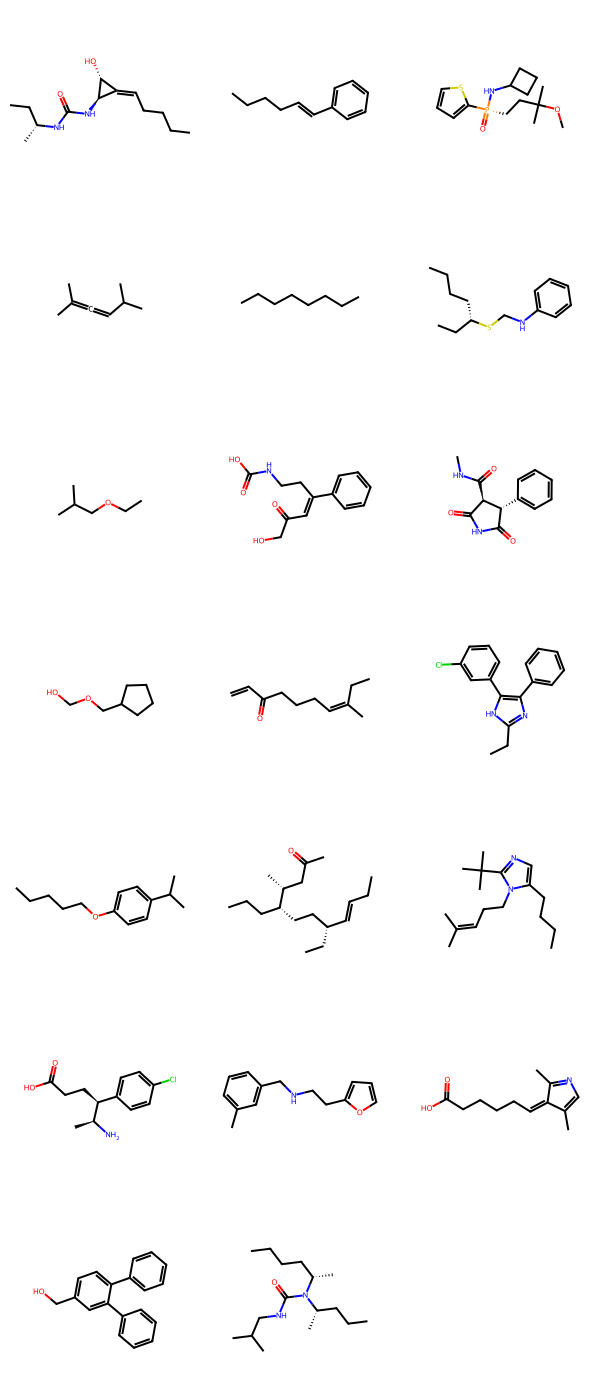

In [2]:
from rdkit import Chem
from rdkit.Chem import Draw

sup = Chem.SDMolSupplier("./data/CHEMBL63_P10000009_fine_tuned_dsteps_10_latest.sdf")

mols = [Chem.MolFromSmiles(Chem.MolToSmiles(x)) for x in sup]

Draw.MolsToGridImage(mols[:20])